In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


import libraries

In [35]:
df = pd.read_csv("fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


load dataset

In [36]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
df.shape

(17880, 18)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

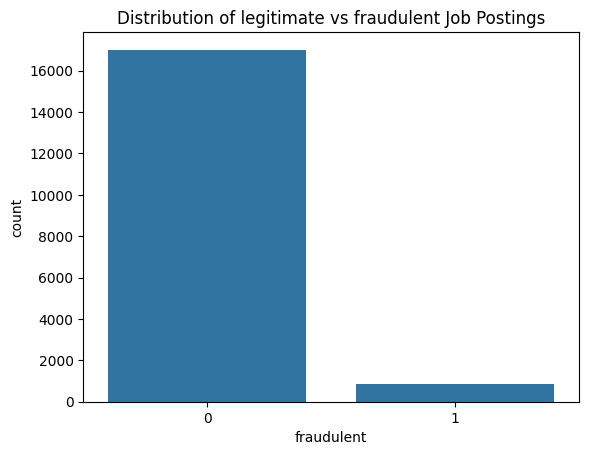

In [39]:
plt.figure()
sns.countplot(x='fraudulent', data = df)
plt.title("Distribution of legitimate vs fraudulent Job Postings")
plt.show()

**data cleaning**

In [40]:
missing_values = df.isnull().sum()
missing_table = pd.DataFrame({
    "Feature": missing_values.index,
    "Missing Values": missing_values.values
})

missing_table = missing_table.sort_values(by="Missing Values", ascending=False)

print(missing_table)

                Feature  Missing Values
4          salary_range           15012
3            department           11547
14   required_education            8105
8              benefits            7212
13  required_experience            7050
16             function            6455
15             industry            4903
12      employment_type            3471
5       company_profile            3308
7          requirements            2696
2              location             346
6           description               1
1                 title               0
0                job_id               0
9         telecommuting               0
11        has_questions               0
10     has_company_logo               0
17           fraudulent               0


check missing value

In [41]:
df = df.drop (columns=[
    "job_id",
])

drop unused columns

In [42]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

In [43]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [44]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

numerical filling missing value

In [45]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 281
Dataset shape after removing duplicates: (17599, 17)


remove duplicate row

In [46]:
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,Unknown,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Unknown,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,Unknown,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,Unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Unknown,0,1,0,Unknown,Unknown,Unknown,Unknown,Unknown,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Unknown,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",Unknown,Unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**feature engineering**

In [47]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [48]:
for col in categorical_cols:
   df[col] = encoder.fit_transform(df[col].astype(str))

encoding categorical data

**Feature selection**

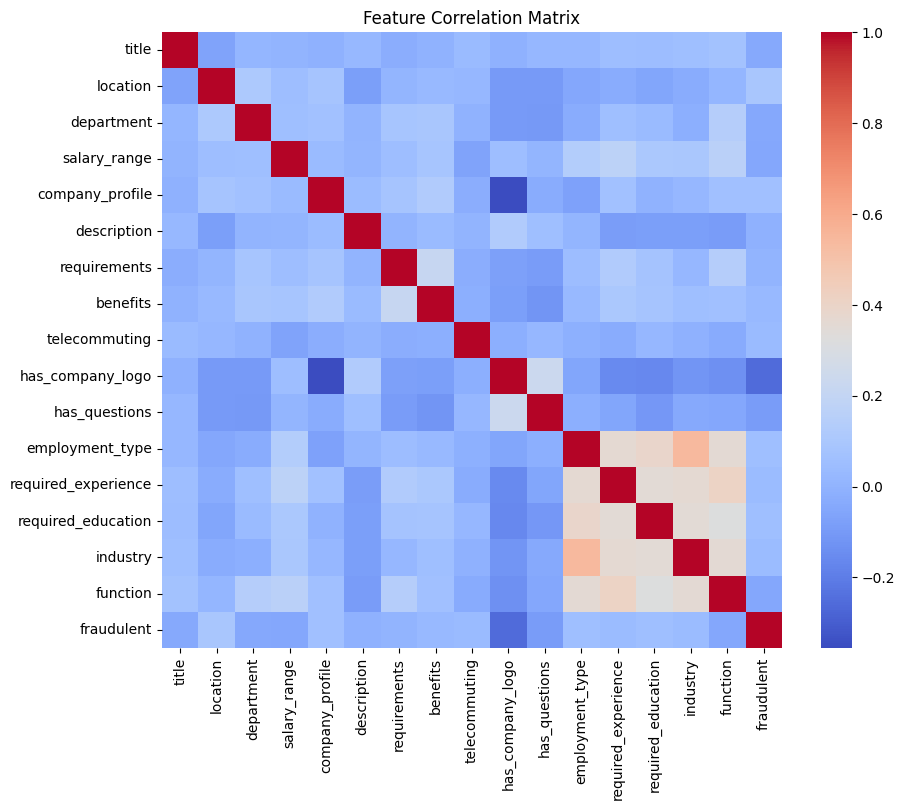

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [50]:
features_to_drop = [
    'salary_range',
    'department',
    'benefits'
]

df = df.drop(columns=features_to_drop)

print("Remaining features:")
print(df.columns)

X = df.drop('fraudulent', axis=1)
y = df['fraudulent']

Remaining features:
Index(['title', 'location', 'company_profile', 'description', 'requirements',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')


**train test split**

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (14079, 13)
Testing Set: (3520, 13)


**feature Scaling**

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standarization

**model implement**

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [54]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [55]:
print("Random Forest Sample Predictions:")
print(rf_predictions[:200])

print("Logistic Regression Sample Predictions:")
print(log_predictions[:200])

Random Forest Sample Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
Logistic Regression Sample Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [56]:
print("Random Forest prediction distribution:")
print(np.bincount(rf_predictions))

print("Logistic Regression prediction distribution:")
print(np.bincount(log_predictions))

Random Forest prediction distribution:
[3421   99]
Logistic Regression prediction distribution:
[3510   10]


In [57]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)
log_accuracy = accuracy_score(y_test, log_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Logistic Regression Accuracy:", log_accuracy)

Random Forest Accuracy: 0.9784090909090909
Logistic Regression Accuracy: 0.953125


**evaluation metrics**

In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [59]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

log_accuracy = accuracy_score(y_test, log_predictions)
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions)

print("Random Forest Performance")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

print("\nLogistic Regression Performance")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1 Score:", log_f1)

Random Forest Performance
Accuracy: 0.9784090909090909
Precision: 0.9797979797979798
Recall: 0.5672514619883041
F1 Score: 0.7185185185185186

Logistic Regression Performance
Accuracy: 0.953125
Precision: 0.8
Recall: 0.04678362573099415
F1 Score: 0.08839779005524862


In [60]:
from sklearn.metrics import classification_report
print("Random Forest Classification Report")
print(classification_report(y_test, rf_predictions))

print("Logistic Regression Classification Report")
print(classification_report(y_test, log_predictions))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3349
           1       0.98      0.57      0.72       171

    accuracy                           0.98      3520
   macro avg       0.98      0.78      0.85      3520
weighted avg       0.98      0.98      0.98      3520

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3349
           1       0.80      0.05      0.09       171

    accuracy                           0.95      3520
   macro avg       0.88      0.52      0.53      3520
weighted avg       0.95      0.95      0.93      3520



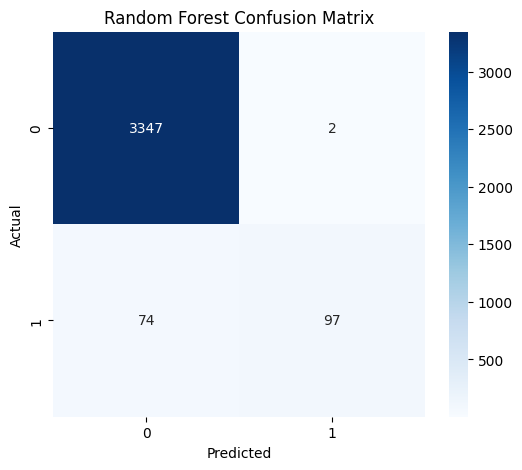

In [64]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

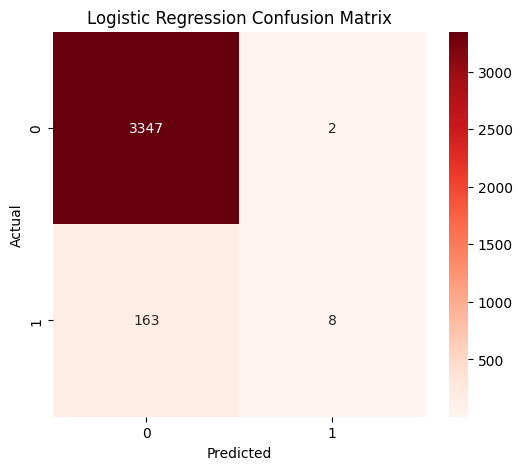

In [66]:
from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(y_test, log_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Reds')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

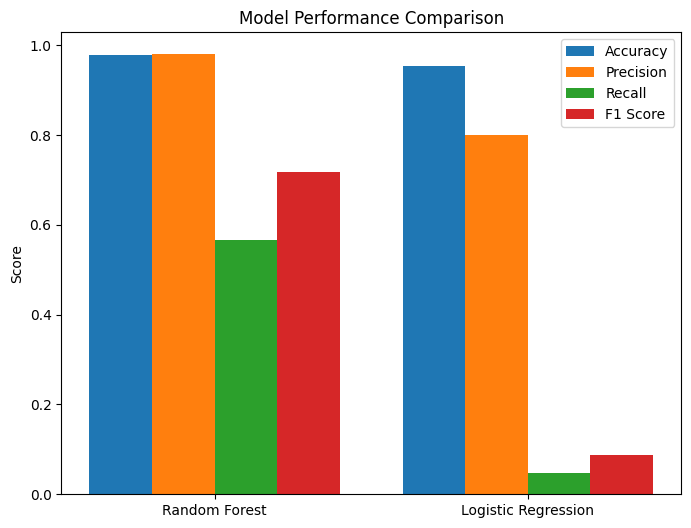

In [65]:
models = ['Random Forest', 'Logistic Regression']

accuracy_scores = [rf_accuracy, log_accuracy]
precision_scores = [rf_precision, log_precision]
recall_scores = [rf_recall, log_recall]
f1_scores = [rf_f1, log_f1]

x = np.arange(len(models))

plt.figure(figsize=(8,6))
plt.bar(x - 0.3, accuracy_scores, 0.2, label='Accuracy')
plt.bar(x - 0.1, precision_scores, 0.2, label='Precision')
plt.bar(x + 0.1, recall_scores, 0.2, label='Recall')
plt.bar(x + 0.3, f1_scores, 0.2, label='F1 Score')

plt.xticks(x, models)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()

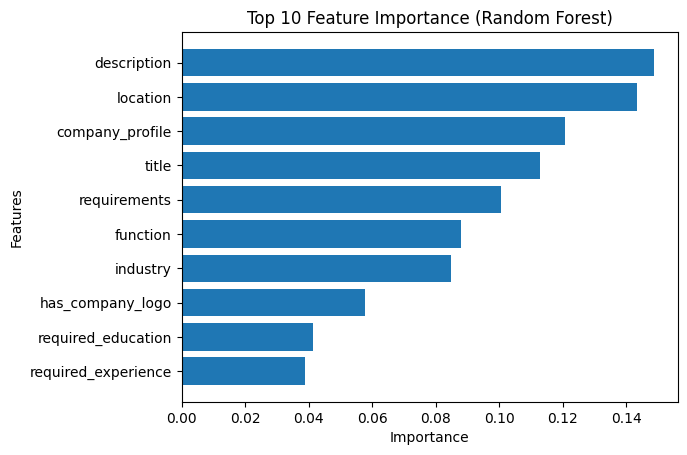

In [67]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()